# Sentiment Analysis Model

This notebook builds a sentiment analysis model for **positive / negative / neutral** text.
It uses:
- text preprocessing
- tokenization
- stop-word removal
- lemmatization
- TF-IDF feature extraction
- Logistic Regression and Linear SVM
- evaluation with accuracy and F1
- model saving for basic deployment

In [1]:

import os
import re
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

try:
    import nltk
    from nltk.corpus import stopwords
    from nltk.stem import WordNetLemmatizer
    _NLTK_AVAILABLE = True
except Exception:
    _NLTK_AVAILABLE = False


In [2]:

def ensure_nltk():
    global _STOPWORDS, _LEMMATIZER
    if not _NLTK_AVAILABLE:
        return
    try:
        _STOPWORDS = set(stopwords.words("english"))
    except Exception:
        _STOPWORDS = set(ENGLISH_STOP_WORDS)

    for w in {"no", "nor", "not", "never"}:
        _STOPWORDS.discard(w)

    try:
        _LEMMATIZER = WordNetLemmatizer()
        _ = _LEMMATIZER.lemmatize("tests")
    except Exception:
        _LEMMATIZER = None

_STOPWORDS = None
_LEMMATIZER = None
ensure_nltk()

def get_stopwords():
    return _STOPWORDS if _STOPWORDS is not None else set(ENGLISH_STOP_WORDS)

def get_lemmatizer():
    return _LEMMATIZER

def preprocess_text(text):
    text = "" if text is None else str(text)
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|@\w+|#\w+", " ", text)
    text = re.sub(r"[^a-z\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = re.findall(r"\b[a-z']+\b", text)

    stop_words = get_stopwords()
    lemmatizer = get_lemmatizer()

    cleaned = []
    for tok in tokens:
        if tok in stop_words:
            continue
        if lemmatizer is not None:
            try:
                tok = lemmatizer.lemmatize(tok)
            except Exception:
                pass
        cleaned.append(tok)
    return " ".join(cleaned)


In [3]:

def normalize_label(value):
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return None
    if isinstance(value, (int, float, np.integer, np.floating)):
        v = float(value)
        if v in {0.0, 1.0}:
            return "positive" if v == 1.0 else "negative"
        if v <= 2:
            return "negative"
        if v == 3:
            return "neutral"
        return "positive"

    s = str(value).strip().lower()
    mapping = {
        "pos": "positive",
        "positive": "positive",
        "neg": "negative",
        "negative": "negative",
        "neu": "neutral",
        "neutral": "neutral",
        "0": "negative",
        "1": "positive",
    }
    if s in mapping:
        return mapping[s]

    try:
        v = float(s)
        if v <= 2:
            return "negative"
        if v == 3:
            return "neutral"
        return "positive"
    except Exception:
        return None


In [4]:

def infer_columns(df):
    lower_cols = {c.lower(): c for c in df.columns}
    text_candidates = ["review", "text", "comment", "tweet", "sentence", "content", "message"]
    label_candidates = ["sentiment", "label", "liked", "rating", "polarity", "class", "target"]

    text_col = next((lower_cols[c] for c in text_candidates if c in lower_cols), None)
    label_col = next((lower_cols[c] for c in label_candidates if c in lower_cols), None)

    if text_col is None:
        obj_cols = [c for c in df.columns if df[c].dtype == "object"]
        text_col = obj_cols[0] if obj_cols else df.columns[0]
    if label_col is None:
        others = [c for c in df.columns if c != text_col]
        label_col = others[0]
    return text_col, label_col

def load_dataset(path=None):
    if path and Path(path).exists():
        p = Path(path)
        if p.suffix.lower() in {".tsv", ".txt"}:
            return pd.read_csv(p, sep="\t")
        return pd.read_csv(p)

    demo = [
        ("I loved the food and the service was excellent.", "positive"),
        ("This was the worst restaurant experience ever.", "negative"),
        ("The product works as expected.", "neutral"),
        ("Amazing quality and super fast delivery!", "positive"),
        ("The update did not fix the issue.", "negative"),
        ("It is okay, nothing special.", "neutral"),
        ("Great value for the money.", "positive"),
        ("I would not recommend this to anyone.", "negative"),
        ("Delivery was on time and the packaging was neat.", "positive"),
        ("The app is usable but has room for improvement.", "neutral"),
        ("Absolutely terrible, the order arrived cold.", "negative"),
        ("The movie was fine, average overall.", "neutral"),
        ("I am very happy with this purchase.", "positive"),
        ("The support team never replied to my message.", "negative"),
        ("The review is mixed; some parts were good, some bad.", "neutral"),
        ("The movie was fantastic!","positive"),
        ("I love this phone", "positive"),
        ("Amazing service", "positive"),
        ("Very happy with the product", "positive"),
        ("Worst app ever", "negative"),
        ("I hate this", "negative"),
        ("Terrible experience", "negative"),
        ("It is okay", "neutral"),
        ("Average quality", "neutral"),
        ("Nothing special", "neutral"),
        ("The laptop performance is outstanding.", "positive"),
        ("Customer care solved my problem quickly.", "positive"),
        ("This restaurant serves delicious meals.", "positive"),
        ("The vacation was relaxing and enjoyable.", "positive"),
        ("Beautiful interface and smooth experience.", "positive"),
        ("I am impressed by the battery life.", "positive"),
        ("The teacher explained everything clearly.", "positive"),
        ("My order arrived earlier than expected.", "positive"),
        ("The screen stopped working after a week.", "negative"),
        ("I regret spending money on this item.", "negative"),
        ("The customer representative was rude.", "negative"),
        ("Installation was confusing and frustrating.", "negative"),
        ("The sound quality is extremely poor.", "negative"),
        ("My food arrived cold and tasteless.", "negative"),
        ("The event started at 7 PM.", "neutral"),
        ("Battery backup lasts around five hours.", "neutral"),
        ("The room size is medium.", "neutral"),
        ("This phone comes in three colors.", "neutral"),
        ("The meeting lasted about thirty minutes.", "neutral"),
        ("The product was delivered yesterday.", "neutral"),
        ("Internet speed is acceptable for browsing.", "neutral"),
        ("The employee was rude and disrespectful.", "negative"),
        ("Customer support was extremely rude.", "negative"),
        ("I am frustrated with this service.", "negative"),
        ("The app is annoying and slow.", "negative"),
        ("Very poor customer experience.", "negative"),
        ("The waiter behaved badly.", "negative"),
        ("The package arrived this morning.", "neutral"),
        ("The meeting starts at 10 AM.", "neutral"),
        ("This phone has a 6-inch screen.", "neutral"),
        ("The product is available in blue color.", "neutral"),
        ("Delivery took three days.", "neutral"),
        ("The software requires an internet connection.", "neutral"),
        ("The room contains two chairs and a table.", "neutral"),
        ("The battery lasts for six hours.", "neutral"),
        ("This restaurant opens at noon.", "neutral"),
        ("The update added new settings.", "neutral"),
        ("I love this product.", "positive"),
        ("The service was excellent.", "positive"),
        ("I am very happy with the results.", "positive"),
        ("The staff were friendly and helpful.", "positive"),
        ("This is the best experience ever.", "positive"),
        ("The food tasted amazing.", "positive"),
        ("I enjoyed the movie a lot.", "positive"),
        ("Everything worked perfectly.", "positive"),
        ("The app is very fast and useful.", "positive"),
        ("I appreciate the quick response.", "positive"),
        ("The concert was fantastic.", "positive"),
        ("The package arrived safely and quickly.", "positive"),
        ("I am satisfied with the purchase.", "positive"),
    ]
    return pd.DataFrame(demo, columns=["text", "label"])

def build_dataset(df, text_col=None, label_col=None):
    if text_col is None or label_col is None:
        text_col, label_col = infer_columns(df)
    out = df[[text_col, label_col]].copy()
    out.columns = ["text", "label"]
    out["label"] = out["label"].apply(normalize_label)
    out["text"] = out["text"].fillna("").astype(str)
    out = out.dropna(subset=["label"])
    out = out[out["text"].str.strip().ne("")]
    out = out[out["text"].str.len() > 0]
    return out.reset_index(drop=True)


In [5]:

# Change this path to your dataset if you have one.
# Example: data_path = "Restaurant_Reviews.tsv"
data_path = ""

raw = load_dataset(data_path if data_path else None)
df = build_dataset(raw)

print(df.head())
print("Shape:", df.shape)
print(df["label"].value_counts())


                                              text     label
0  I loved the food and the service was excellent.  positive
1   This was the worst restaurant experience ever.  negative
2                   The product works as expected.   neutral
3         Amazing quality and super fast delivery!  positive
4                The update did not fix the issue.  negative
Shape: (75, 2)
label
positive    30
neutral     25
negative    20
Name: count, dtype: int64


In [6]:

df["clean_text"] = df["text"].apply(preprocess_text)
df[["text", "clean_text", "label"]].head(10)


,text,clean_text,label
0,I loved the food and the service was excellent.,loved food service excellent,positive
1,This was the worst restaurant experience ever.,worst restaurant experience ever,negative
2,The product works as expected.,product work expected,neutral
3,Amazing quality and super fast delivery!,amazing quality super fast delivery,positive
4,The update did not fix the issue.,update not fix issue,negative
5,"It is okay, nothing special.",okay nothing special,neutral
6,Great value for the money.,great value money,positive
7,I would not recommend this to anyone.,would not recommend anyone,negative
8,Delivery was on time and the packaging was neat.,delivery time packaging neat,positive
9,The app is usable but has room for improvement.,app usable room improvement,neutral


In [7]:

X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"],
    df["label"],
    test_size=0.2,
    random_state=42,
    stratify=df["label"] if df["label"].nunique() > 1 else None,
)

vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=1,
    max_df=0.95,
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "Linear SVM": LinearSVC(class_weight="balanced"),
}

results = {}
trained_models = {}

for name, model in models.items():
    model.fit(X_train_vec, y_train)
    preds = model.predict(X_test_vec)
    results[name] = {
        "accuracy": accuracy_score(y_test, preds),
        "f1_macro": f1_score(y_test, preds, average="macro"),
        "report": classification_report(y_test, preds, zero_division=0),
        "cm": confusion_matrix(y_test, preds, labels=sorted(df["label"].unique())),
    }
    trained_models[name] = model

results


{'Logistic Regression': {'accuracy': 0.7333333333333333,
  'f1_macro': 0.7277777777777779,
  'report': '              precision    recall  f1-score   support\n\n    negative       0.75      0.75      0.75         4\n     neutral       0.71      1.00      0.83         5\n    positive       0.75      0.50      0.60         6\n\n    accuracy                           0.73        15\n   macro avg       0.74      0.75      0.73        15\nweighted avg       0.74      0.73      0.72        15\n',
  'cm': array([[3, 0, 1],
         [0, 5, 0],
         [1, 2, 3]])},
 'Linear SVM': {'accuracy': 0.8,
  'f1_macro': 0.7954545454545455,
  'report': '              precision    recall  f1-score   support\n\n    negative       0.75      0.75      0.75         4\n     neutral       0.83      1.00      0.91         5\n    positive       0.80      0.67      0.73         6\n\n    accuracy                           0.80        15\n   macro avg       0.79      0.81      0.80        15\nweighted avg       0.

In [8]:

for name, info in results.items():
    print(f"===== {name} =====")
    print("Accuracy:", round(info["accuracy"], 4))
    print("Macro F1:", round(info["f1_macro"], 4))
    print(info["report"])


===== Logistic Regression =====
Accuracy: 0.7333
Macro F1: 0.7278
              precision    recall  f1-score   support

    negative       0.75      0.75      0.75         4
     neutral       0.71      1.00      0.83         5
    positive       0.75      0.50      0.60         6

    accuracy                           0.73        15
   macro avg       0.74      0.75      0.73        15
weighted avg       0.74      0.73      0.72        15

===== Linear SVM =====
Accuracy: 0.8
Macro F1: 0.7955
              precision    recall  f1-score   support

    negative       0.75      0.75      0.75         4
     neutral       0.83      1.00      0.91         5
    positive       0.80      0.67      0.73         6

    accuracy                           0.80        15
   macro avg       0.79      0.81      0.80        15
weighted avg       0.80      0.80      0.79        15



In [9]:

best_name = max(results, key=lambda n: results[n]["f1_macro"])
best_model = trained_models[best_name]

print("Best model:", best_name)
print(results[best_name]["cm"])


Best model: Linear SVM
[[3 0 1]
 [0 5 0]
 [1 1 4]]


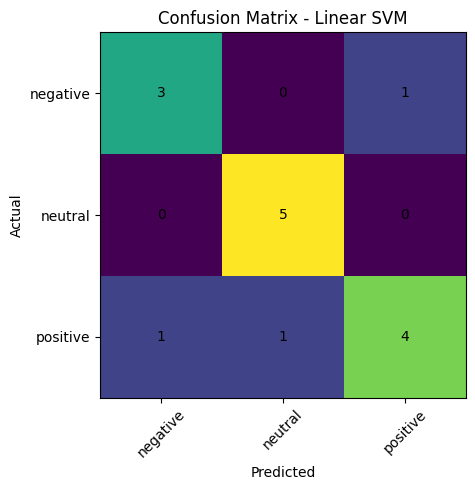

In [10]:

fig, ax = plt.subplots(figsize=(6, 5))
cm = results[best_name]["cm"]
labels = sorted(df["label"].unique())
im = ax.imshow(cm, interpolation="nearest")
ax.set_title(f"Confusion Matrix - {best_name}")
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45)
ax.set_yticklabels(labels)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center")
plt.tight_layout()
plt.show()


In [11]:

def predict_sentiment(text):
    cleaned = preprocess_text(text)
    vec = vectorizer.transform([cleaned])
    return best_model.predict(vec)[0]

samples = [
  "The food was delicious and the staff were kind.",
    "The app keeps crashing and I am frustrated.",
  "The customer representative was rude.",
    "The package contains all listed items.",
    "The event started at 7 PM.",
    "I enjoyed every moment of the concert.",
    "The waiter behaved badly.",
    "The room size is medium.",
    "The app is annoying and slow."
]

for s in samples:
    print(s, "->", predict_sentiment(s))


The food was delicious and the staff were kind. -> positive
The app keeps crashing and I am frustrated. -> negative
The customer representative was rude. -> negative
The package contains all listed items. -> neutral
The event started at 7 PM. -> neutral
I enjoyed every moment of the concert. -> positive
The waiter behaved badly. -> negative
The room size is medium. -> neutral
The app is annoying and slow. -> negative


## Save the model

The vectorizer and the best trained model are saved with `joblib`.

In [12]:

out_dir = Path("artifacts")
out_dir.mkdir(exist_ok=True)

joblib.dump(vectorizer, out_dir / "tfidf_vectorizer.joblib")
joblib.dump(best_model, out_dir / f"{best_name.replace(' ', '_').lower()}_model.joblib")

print("Saved to:", out_dir.resolve())


Saved to: C:\Users\zak29\Downloads\sentiment_analysis_project\sentiment_project\artifacts


## Basic deployment tips

A simple deployment setup can use:
- **Streamlit** for a quick web app
- **Flask/FastAPI** for an API endpoint
- the saved `.joblib` files for inference

Example idea:
1. Load the vectorizer and model.
2. Accept user text in a form.
3. Run preprocessing + prediction.
4. Show the sentiment label and confidence if the model supports probabilities.